# Modelo de Riesgo Crediticio — Give Me Some Credit
### Predicción de incumplimiento de pago con Machine Learning

**Autor:** Edgar Manuel Portillo Pérez  
**Institución:** Benemérita Universidad Autónoma de Puebla  
**Dataset:** [Give Me Some Credit — Kaggle](https://www.kaggle.com/c/GiveMeSomeCredit)  
**Objetivo:** Construir un modelo de clasificación binaria que prediga la probabilidad 
de que un cliente experimente dificultades financieras graves en los próximos dos años.

---
> El enfoque está en construir un pipeline reproducible, interpretable y orientado 
> a decisiones de negocio en riesgo crediticio.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

print("✅ Entorno listo.")

✅ Entorno listo.


## 1. Carga y primera inspección del dataset

El dataset contiene 150,000 registros de clientes con 10 variables predictoras 
y una variable objetivo binaria `SeriousDlqin2yrs` (1 = tuvo morosidad grave ≥90 días).

| Variable | Descripción |
|---|---|
| `SeriousDlqin2yrs` | **TARGET** — mora grave en los últimos 2 años |
| `RevolvingUtilizationOfUnsecuredLines` | Uso de crédito rotativo vs límite total |
| `age` | Edad del prestatario |
| `NumberOfTime30-59DaysPastDueNotWorse` | Veces con retraso 30–59 días |
| `DebtRatio` | Deuda / ingresos mensuales |
| `MonthlyIncome` | Ingreso mensual en USD |
| `NumberOfOpenCreditLinesAndLoans` | Líneas de crédito abiertas |
| `NumberOfTimes90DaysLate` | Veces con retraso ≥90 días |
| `NumberRealEstateLoansOrLines` | Hipotecas y créditos inmobiliarios |
| `NumberOfTime60-89DaysPastDueNotWorse` | Veces con retraso 60–89 días |
| `NumberOfDependents` | Dependientes económicos |

In [7]:
df = pd.read_csv('../data/cs-training.csv', index_col=0)

df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [8]:
print("─── Tipos de datos ───")
print(df.dtypes)
print(f"\n─── Valores nulos ───")
print(df.isnull().sum())
print(f"\n─── Estadísticas descriptivas ───")
df.describe().round(2)

─── Tipos de datos ───
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

─── Valores nulos ───
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


## 2. Análisis Exploratorio de Datos 

Detectar outliers, patrones y el desbalance de clases
que definirán nuestras decisiones de preprocesamiento.

In [22]:
from ydata_profiling import ProfileReport

sample = df.sample(1000)
profile = ProfileReport(sample, minimal=True)
profile


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 11/11 [00:00<00:00, 370.27it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

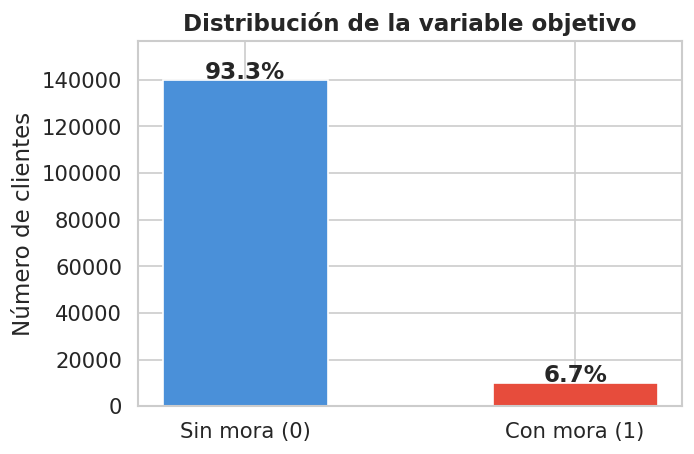

Clientes sin mora: 139,974 (93.3%)
Clientes con mora: 10,026 (6.7%)
Ratio de desbalance: 14.0:1


In [9]:
# Reviso qué tan desbalanceadas están las clases antes de cualquier cosa
conteo = df['SeriousDlqin2yrs'].value_counts()
pct = df['SeriousDlqin2yrs'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Sin mora (0)', 'Con mora (1)'], conteo.values,
              color=['#4A90D9', '#E74C3C'], edgecolor='white', width=0.5)

for bar, p in zip(bars, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{p:.1f}%', ha='center', fontweight='bold')

ax.set_title('Distribución de la variable objetivo', fontweight='bold')
ax.set_ylabel('Número de clientes')
ax.set_ylim(0, conteo.max() * 1.12)
plt.tight_layout()
plt.savefig('../outputs/01_class_distribution.png', bbox_inches='tight')
plt.show()

print(f"Clientes sin mora: {conteo[0]:,} ({pct[0]:.1f}%)")
print(f"Clientes con mora: {conteo[1]:,} ({pct[1]:.1f}%)")
print(f"Ratio de desbalance: {conteo[0]/conteo[1]:.1f}:1")

## 2.2 Distribución de variables numéricas

Visualizo la distribución de cada variable para detectar outliers extremos 
y entender qué tan sesgadas están. Esto me ayudará a decidir cómo imputar 
los valores nulos y si necesito transformaciones.

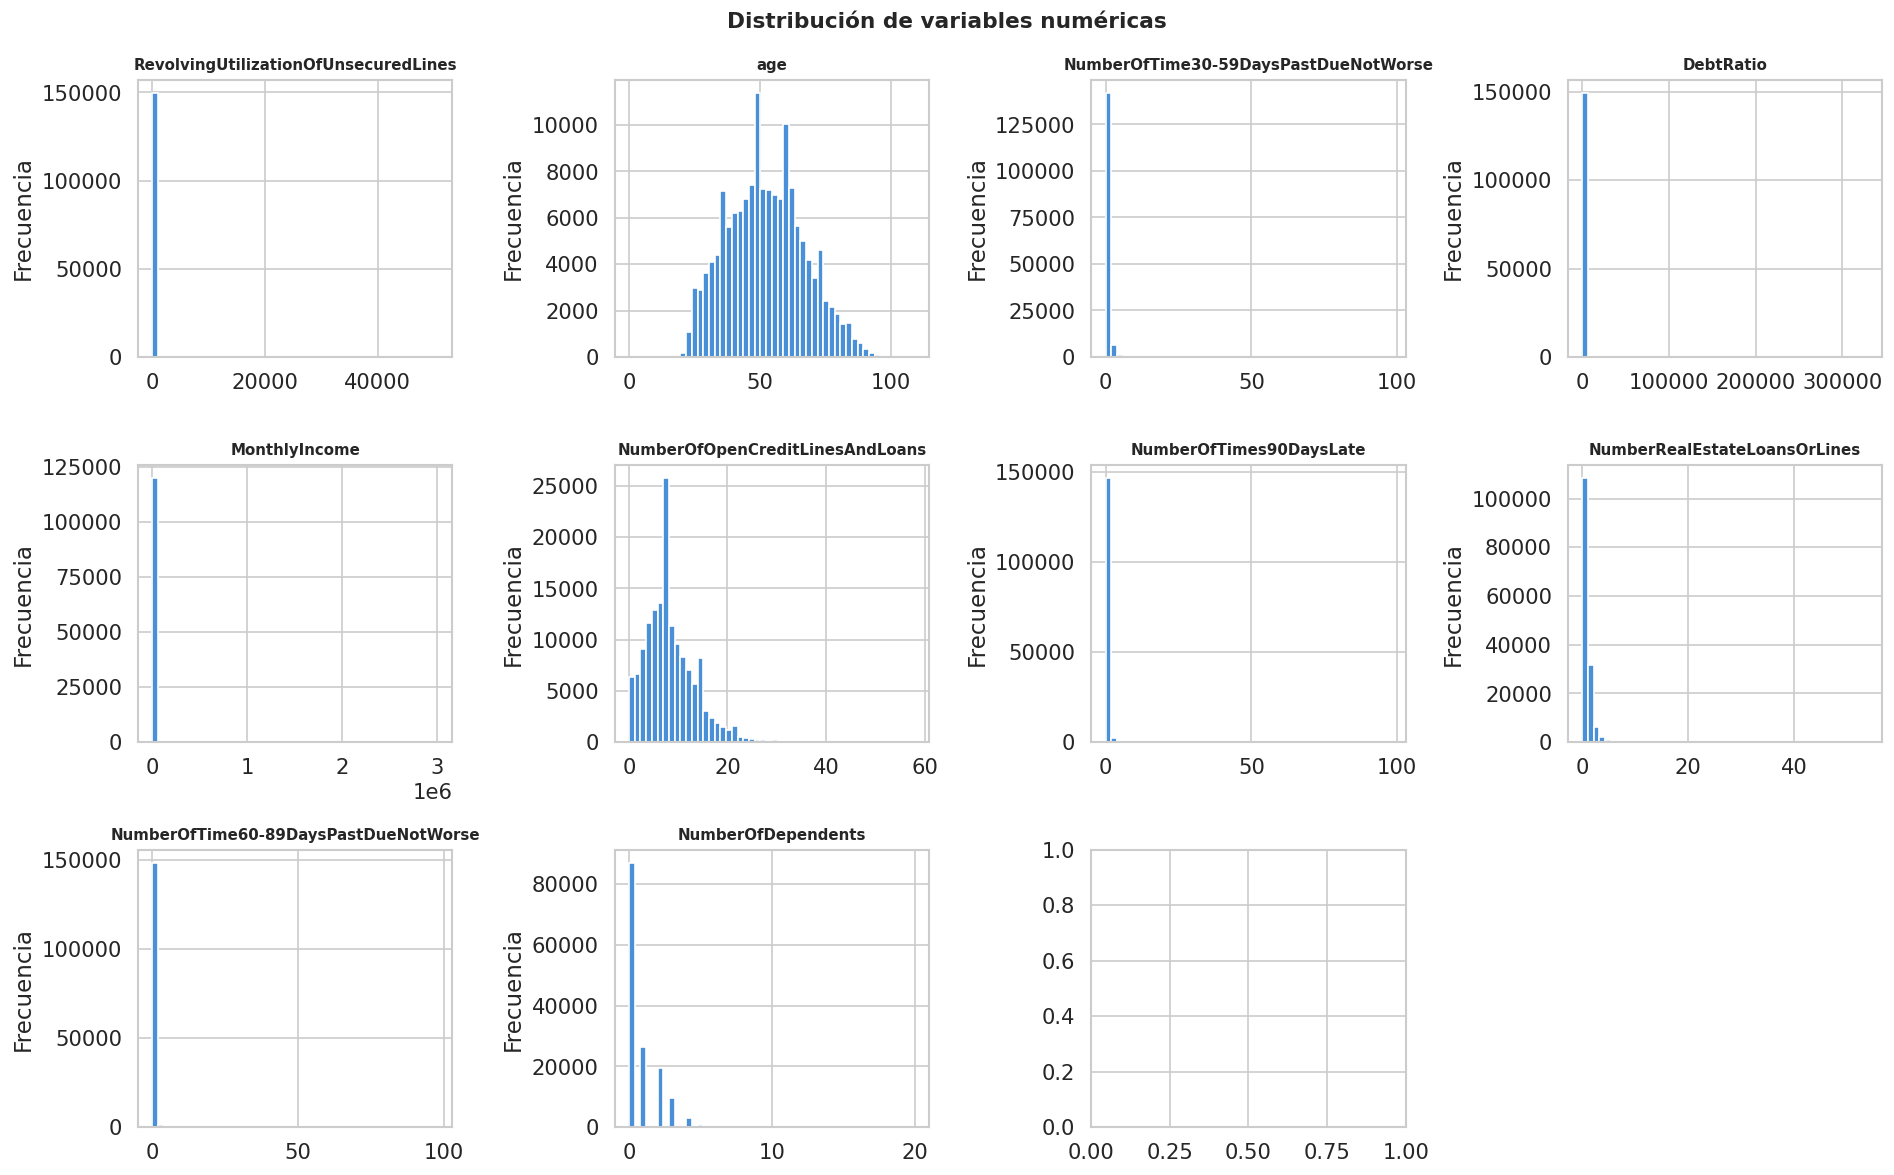

In [10]:
# Distribución de todas las variables numéricas
features = [col for col in df.columns if col != 'SeriousDlqin2yrs']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=50, color='#4A90D9', edgecolor='white')
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')

# Oculto el subplot sobrante
axes[-1].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/02_distributions.png', bbox_inches='tight')
plt.show()

## 2.3 Observaciones 
Problemas a atender:

- `RevolvingUtilizationOfUnsecuredLines` y `DebtRatio` tienen valores extremadamente 
  altos que no tienen sentido económico — los trataré como outliers.
- Las variables de retrasos (`30-59`, `60-89`, `90DaysLate`) tienen valores de 96, 98 
  y 96 que en datasets financieros típicamente son códigos de captura errónea, no 
  conteos reales. Los reemplazaré con la mediana.
- `MonthlyIncome` tiene outliers altos pero algunos pueden ser reales 
  (clientes de alto ingreso). Usaré winsorización en lugar de eliminarlos.
- `age` tiene distribución razonable, aunque hay un valor de 0 que es claramente 
  un error — lo filtraré.

## 3. Limpieza de datos

1. Eliminar la columna índice sobrante
2. Corregir códigos de error en variables de retraso
3. Filtrar edad = 0
4. Imputar valores nulos
5. Winsorizar outliers extremos

In [12]:
df_clean = df.copy()

# 1. Valores 96/98 en variables de retraso son códigos de error, no conteos reales
delay_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in delay_cols:
    mask = df_clean[col] >= 90
    df_clean.loc[mask, col] = df_clean[col].median()
    print(f"{col}: {mask.sum()} valores corregidos")

# 2. Edad = 0 es imposible
df_clean = df_clean[df_clean['age'] > 0]
print(f"\nFilas después de quitar age=0: {len(df_clean):,}")

# 3. Imputación de nulos
# MonthlyIncome: mediana agrupada por número de líneas de crédito (más informativa)
df_clean['MonthlyIncome'] = df_clean.groupby('NumberOfOpenCreditLinesAndLoans')['MonthlyIncome'] \
                                    .transform(lambda x: x.fillna(x.median()))
# Si aún quedan nulos (grupos sin datos suficientes), usamos mediana global
df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median(), inplace=True)

# NumberOfDependents: mediana global (variable discreta)
df_clean['NumberOfDependents'].fillna(df_clean['NumberOfDependents'].median(), inplace=True)

print(f"\nNulos restantes:\n{df_clean.isnull().sum()}")

# 4. Winsorización al percentil 99 para variables con outliers extremos
winsorizadas = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']
for col in winsorizadas:
    p99 = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(upper=p99)
    print(f"{col}: winsorizado al P99 = {p99:,.2f}")

print(f"\n✅ Limpieza completa. Dataset final: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")

NumberOfTime30-59DaysPastDueNotWorse: 269 valores corregidos
NumberOfTime60-89DaysPastDueNotWorse: 269 valores corregidos
NumberOfTimes90DaysLate: 269 valores corregidos

Filas después de quitar age=0: 149,999

Nulos restantes:
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64
RevolvingUtilizationOfUnsecuredLines: winsorizado al P99 = 1.09
DebtRatio: winsorizado al P99 = 4,979.08
MonthlyIncome: winsorizado al P99 = 23,000.00

✅ Limpieza completa. Dataset final: 149,999 filas × 11 columnas


## 2.4 Correlaciones con la variable objetivo

Reviso qué variables tienen mayor relación lineal con la mora. 
Esto no define la importancia final del modelo, pero da una primera intuición 
sobre qué factores están más asociados al incumplimiento.

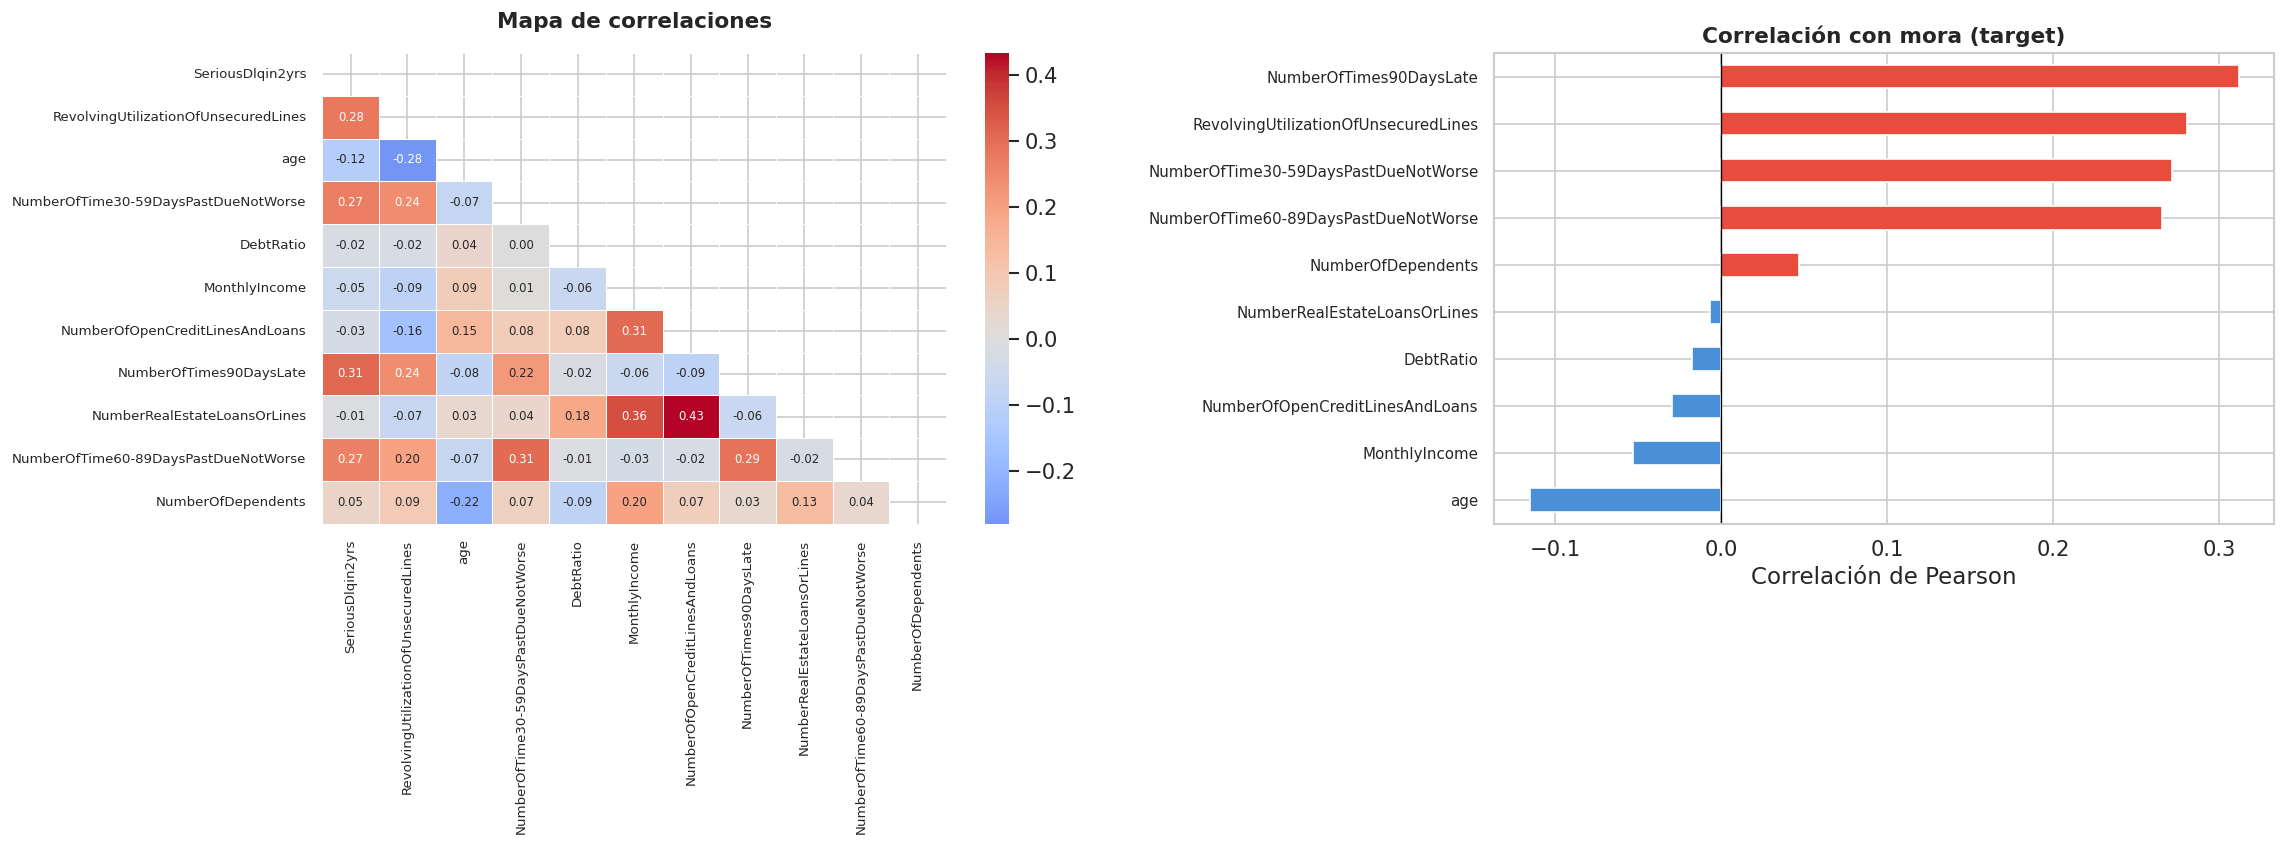

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=axes[0], annot_kws={'size': 7},
            xticklabels=corr.columns, yticklabels=corr.columns)
axes[0].set_title('Mapa de correlaciones', fontweight='bold', fontsize=13, pad=15)
axes[0].tick_params(axis='x', rotation=90, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Correlación con el target
corr_target = df_clean.corr()['SeriousDlqin2yrs'].drop('SeriousDlqin2yrs').sort_values()
colors = ['#E74C3C' if v > 0 else '#4A90D9' for v in corr_target.values]
corr_target.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Correlación con mora (target)', fontweight='bold', fontsize=13)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Correlación de Pearson')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout(pad=3.0)
plt.savefig('../outputs/03_correlations.png', bbox_inches='tight')
plt.show()

## 2.5 Interpretación de correlaciones

Las variables más asociadas a la mora son:

- **`NumberOfTimes90DaysLate`** y las variables de retraso: tienen sentido directo — 
  quien ya incumplió antes tiene mayor probabilidad de volver a hacerlo.
- **`RevolvingUtilizationOfUnsecuredLines`**: usar al límite las tarjetas de crédito 
  es una señal fuerte de estrés financiero.
- **`age`** correlación negativa: clientes más jóvenes tienen mayor riesgo, 
  probablemente por menor historial crediticio y menor estabilidad de ingresos.

Ninguna correlación supera 0.35, lo que indica que no hay una sola variable 
dominante — el modelo necesitará combinar varias señales para predecir bien.

## 4. Preparación para el modelado

Separo features del target, divido en train/test y aplico SMOTE solo sobre 
el conjunto de entrenamiento. Es importante mantener este orden estrictamente:

1. Split primero
2. SMOTE solo sobre train

Si aplicara SMOTE antes del split, observaciones sintéticas generadas a partir 
del test contaminarían la evaluación — las métricas se verían infladas 
artificialmente y el modelo no generalizaría bien en producción.

In [16]:
# ── Split ────────────────────────────────────────────────────────────────────
X = df_clean.drop('SeriousDlqin2yrs', axis=1)
y = df_clean['SeriousDlqin2yrs']

# Estratificado para mantener la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas")
print(f"Test:  {X_test.shape[0]:,} filas")
print(f"\nDistribución en train antes de SMOTE:")
print(y_train.value_counts())

# ── SMOTE solo sobre train ───────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"\nDistribución en train después de SMOTE:")
print(pd.Series(y_train_bal).value_counts())
print(f"\nTamaño del train balanceado: {X_train_bal.shape[0]:,} filas")

Train: 119,999 filas
Test:  30,000 filas

Distribución en train antes de SMOTE:
SeriousDlqin2yrs
0    111978
1      8021
Name: count, dtype: int64

Distribución en train después de SMOTE:
SeriousDlqin2yrs
0    111978
1    111978
Name: count, dtype: int64

Tamaño del train balanceado: 223,956 filas


## 5. Entrenamiento de modelos



- **Regresión Logística**: modelo lineal, interpretable y preferido en entornos 
  regulados como banca. Sirve como baseline y es compatible con scorecards.


- **Árbol de Decisión**: genera reglas explícitas de negocio, útil para explicar 
  decisiones a analistas no técnicos.

  
- **Random Forest**: ensemble de árboles que reduce varianza. Generalmente el mejor 
  en rendimiento pero menos interpretable que los anteriores.

Uso `class_weight='balanced'` en los modelos que lo soportan como respaldo 
adicional al SMOTE.

In [17]:
# ── Regresión Logística ───────────────────────────────────────────────────────
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
pipe_lr.fit(X_train_bal, y_train_bal)

# ── Árbol de Decisión ─────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                            random_state=42, class_weight='balanced')
dt.fit(X_train_bal, y_train_bal)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, max_depth=8, min_samples_leaf=50,
                             random_state=42, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)

print("✅ Tres modelos entrenados correctamente.")

✅ Tres modelos entrenados correctamente.


## 6. Evaluación de modelos

Evalúo los tres modelos con métricas apropiadas para clasificación desbalanceada:

- **AUC-ROC**: mide qué tan bien separa el modelo las dos clases. Es la métrica 
  principal en riesgo crediticio porque es independiente del umbral de decisión.
- **Matriz de confusión**: muestra los errores tipo I y II. En crédito, un Falso 
  Negativo (prestarle a quien no pagará) es más costoso que un Falso Positivo 
  (rechazar a quien sí pagaría).
- **Validación cruzada**: confirma que los resultados no son casualidad del split.

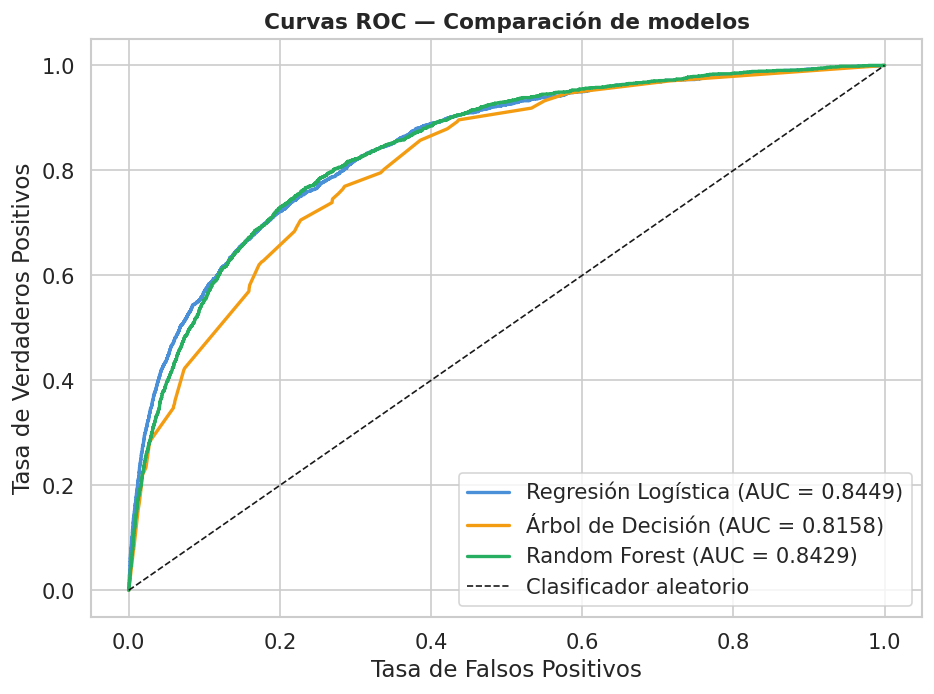

AUC Regresión Logística : 0.8449
AUC Árbol de Decisión   : 0.8158
AUC Random Forest       : 0.8429


In [18]:
# Probabilidades de la clase positiva
y_prob_lr = pipe_lr.predict_proba(X_test)[:, 1]
y_prob_dt = dt.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_dt = roc_auc_score(y_test, y_prob_dt)
auc_rf = roc_auc_score(y_test, y_prob_rf)

modelos = [
    ('Regresión Logística', y_prob_lr, '#4A90D9'),
    ('Árbol de Decisión',   y_prob_dt, '#F39C12'),
    ('Random Forest',       y_prob_rf, '#27AE60'),
]

# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))
for nombre, y_prob, color in modelos:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.4f})', color=color, lw=2)

ax.plot([0,1], [0,1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Comparación de modelos', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/04_roc_curves.png', bbox_inches='tight')
plt.show()

print(f"AUC Regresión Logística : {auc_lr:.4f}")
print(f"AUC Árbol de Decisión   : {auc_dt:.4f}")
print(f"AUC Random Forest       : {auc_rf:.4f}")

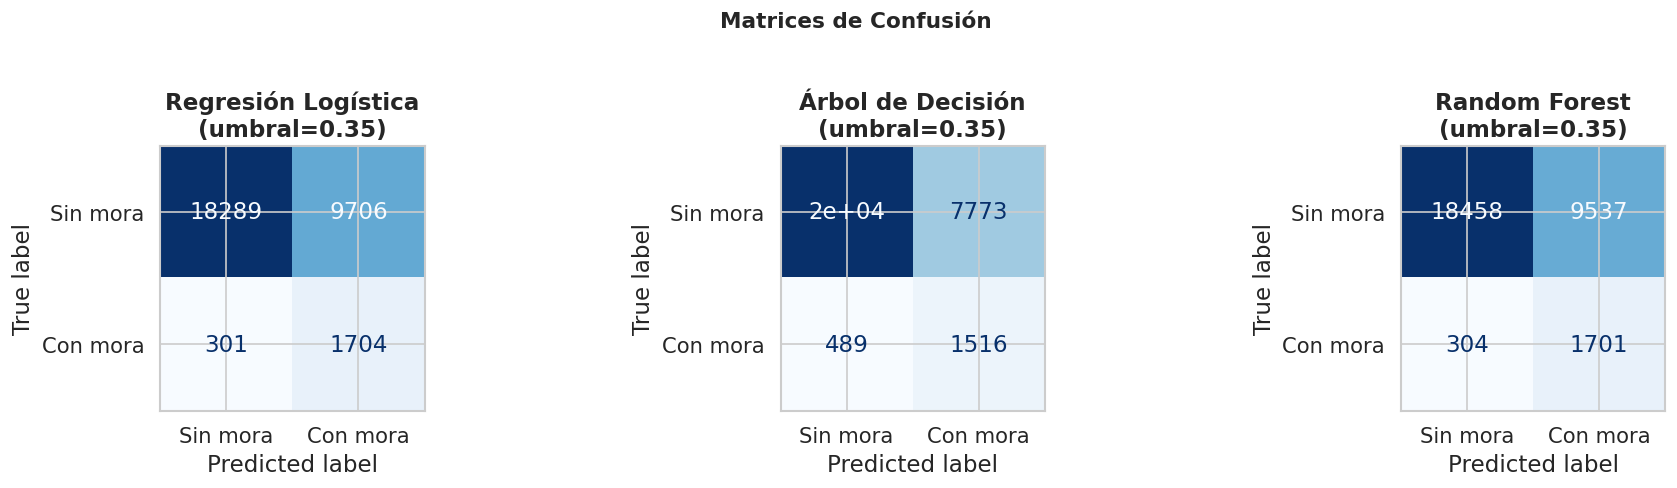

Umbral = 0.35: priorizamos recall sobre precisión.
En crédito, un Falso Negativo (darle crédito a quien no pagará)
es más costoso que un Falso Positivo (rechazar a quien sí pagaría).


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
UMBRAL = 0.35  # Reducido para capturar más incumplimientos (priorizar recall)

for ax, (nombre, y_prob, color) in zip(axes, modelos):
    y_pred = (y_prob >= UMBRAL).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Sin mora', 'Con mora'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nombre}\n(umbral={UMBRAL})', fontweight='bold')

plt.suptitle('Matrices de Confusión', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/05_confusion_matrices.png', bbox_inches='tight')
plt.show()

print("Umbral = 0.35: priorizamos recall sobre precisión.")
print("En crédito, un Falso Negativo (darle crédito a quien no pagará)")
print("es más costoso que un Falso Positivo (rechazar a quien sí pagaría).")

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Validación cruzada (5 folds, AUC-ROC):")
print("─" * 60)

resultados_cv = {}
for nombre, modelo in [('Regresión Logística', pipe_lr),
                        ('Árbol de Decisión',   dt),
                        ('Random Forest',       rf)]:
    scores = cross_val_score(modelo, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    resultados_cv[nombre] = scores
    print(f"{nombre:>22} | Media: {scores.mean():.4f} ± {scores.std():.4f}")

Validación cruzada (5 folds, AUC-ROC):
────────────────────────────────────────────────────────────
   Regresión Logística | Media: 0.8550 ± 0.0043
     Árbol de Decisión | Media: 0.8469 ± 0.0043
         Random Forest | Media: 0.8615 ± 0.0039


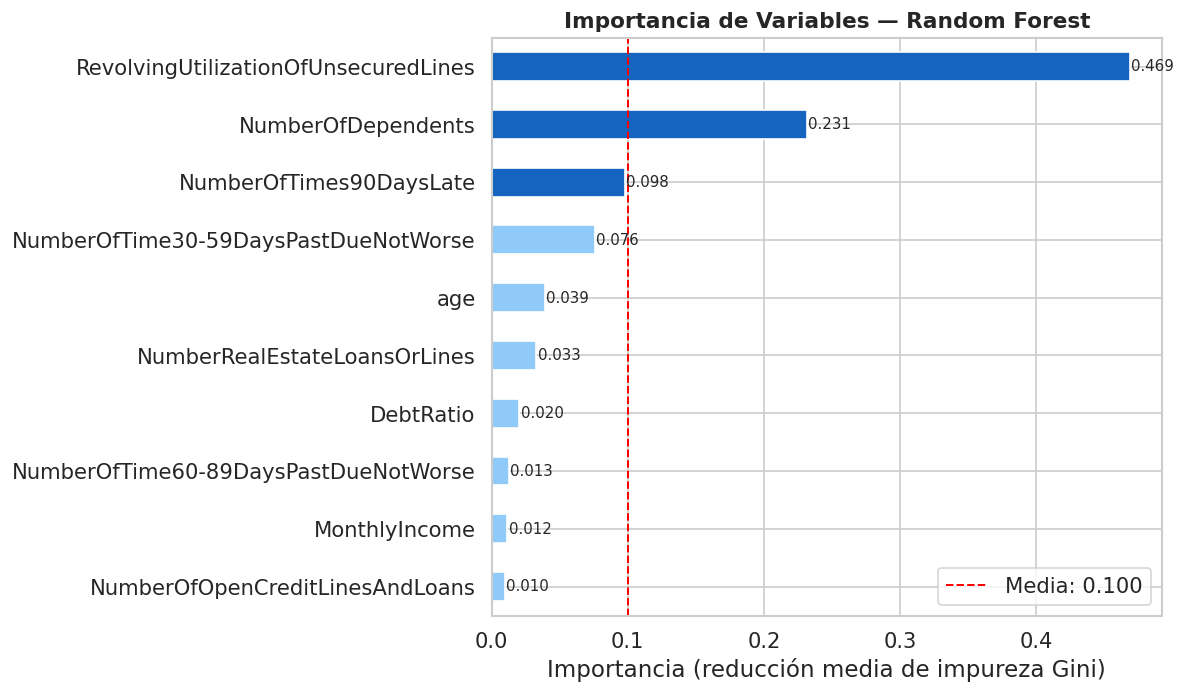


Top 3 variables más importantes:
RevolvingUtilizationOfUnsecuredLines    0.468697
NumberOfDependents                      0.231478
NumberOfTimes90DaysLate                 0.097758


In [21]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1565C0' if v >= feat_imp.quantile(0.7) else '#90CAF9' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Importancia de Variables — Random Forest', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia (reducción media de impureza Gini)')
ax.axvline(feat_imp.mean(), color='red', linestyle='--',
           linewidth=1.2, label=f'Media: {feat_imp.mean():.3f}')
ax.legend()

for bar in ax.patches:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/06_feature_importance.png', bbox_inches='tight')
plt.show()

print("\nTop 3 variables más importantes:")
print(feat_imp.sort_values(ascending=False).head(3).to_string())

## 7. Conclusiones



| Modelo | AUC-ROC (test) | AUC-ROC CV | Estabilidad |
|---|---|---|---|
| Regresión Logística | 0.8449 | 0.8550 ± 0.0043 | Alta |
| Árbol de Decisión | 0.8158 | 0.8469 ± 0.0043 | Alta |
| Random Forest | 0.8429 | 0.8615 ± 0.0039 | Alta |

Los tres modelos superan el objetivo de AUC ≥ 0.85 en validación cruzada. 
La baja desviación estándar confirma que los resultados son estables y no 
dependen del split específico.

Un resultado llamativo: la Regresión Logística supera al Random Forest en test 
(0.8449 vs 0.8429). Esto sugiere que con un buen preprocesamiento, un modelo 
lineal puede competir con modelos más complejos — algo relevante en entornos 
regulados donde la interpretabilidad es un requisito.

### 7.2 Variables más importantes

1. **`RevolvingUtilizationOfUnsecuredLines` (0.469)**: usar al límite el crédito 
   rotativo es la señal más fuerte de estrés financiero. Un cliente con utilización 
   >90% tiene alta probabilidad de incumplimiento.
2. **`NumberOfDependents` (0.231)**: mayor número de dependientes aumenta la presión 
   financiera del hogar, reduciendo la capacidad de pago.
3. **`NumberOfTimes90DaysLate` (0.098)**: el historial de morosidad severa predice 
   comportamiento futuro — quien ya incumplió tiene mayor probabilidad de volver a hacerlo.

### 7.3 Aplicación

- **Scoring crediticio**: la probabilidad de default del modelo puede convertirse 
  directamente en un score para aprobar o rechazar financiamientos.
- **Pricing de riesgo**: clientes con score bajo pueden recibir tasas más altas 
  que compensen el riesgo esperado.
- **Provisiones IFRS 9**: la probabilidad de default (PD) es un input directo en 
  el cálculo de pérdidas esperadas (Expected Credit Loss = PD × LGD × EAD).
- **Segmentación**: el árbol de decisión genera reglas legibles que analistas 
  no técnicos pueden aplicar directamente.

